# Week 04 - Lesson 03: RAG Application Evaluation

This notebook demonstrates how to evaluate **Retrieval-Augmented Generation (RAG) applications** using LangSmith. You'll learn to build comprehensive evaluation systems that measure the quality and performance of enterprise RAG systems.

<img src="https://www.ai21.com/wp-content/uploads/2025/07/rag-evaluation.webp" alt="RAG Evaluation" width="700"/>

#### **Why RAG Evaluation Matters**

- **Quality Assurance**: Ensure accurate information retrieval and generation
- **Performance Monitoring**: Track retrieval and generation quality over time
- **Risk Mitigation**: Detect hallucinations and irrelevant responses
- **Continuous Improvement**: Use evaluation data to enhance RAG systems
- **Enterprise Compliance**: Meet accuracy standards for business applications

#### **RAG Evaluation Framework**

A typical RAG evaluation workflow consists of:
1. **Dataset Creation**: Questions and reference answers
2. **Application Testing**: Run RAG system on test questions
3. **Multi-dimensional Evaluation**: Assess correctness, relevance, groundedness, and retrieval quality

For this tutorial, we'll evaluate an enterprise knowledge assistant that answers questions about business policies and procedures.


---
## 1. Environment Setup and Dependencies


In [1]:
# Install required dependencies
%pip install -U --quiet langsmith langchain langchain-openai langchain-community python-dotenv openai tiktoken


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries
import os
from dotenv import load_dotenv
from typing_extensions import Annotated, TypedDict
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langsmith import Client, traceable


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [ ]:
# Load environment variables
load_dotenv()

# Set up LangSmith environment variables
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_API_KEY'] = 'lsv-your-openai-api-key'
os.environ['LANGSMITH_PROJECT'] = 'rag-evaluation-project'
os.environ['OPENAI_API_KEY'] = 'sk-proj-your-openai-api-key'

# Initialize LangSmith client
client = Client()

---
## 2. Building the Enterprise RAG Application

We'll create a knowledge assistant that answers questions about enterprise business policies and procedures. This RAG system will:

- **Index**: Load and chunk enterprise documentation
- **Retrieve**: Find relevant documents based on user questions  
- **Generate**: Provide accurate answers using retrieved context


### 2.1 Document Loading and Indexing

Let's load enterprise business documentation and create a vector store for retrieval.


In [4]:
# Sample enterprise business documentation URLs
# In practice, these would be internal company documents, wikis, or knowledge bases
enterprise_docs = [
    "https://www.investopedia.com/terms/e/erp.asp",
    "https://www.investopedia.com/terms/c/corporategovernance.asp", 
    "https://www.investopedia.com/terms/r/riskmanagement.asp",
    "https://www.investopedia.com/terms/c/compliance-officer.asp",
    "https://www.investopedia.com/terms/b/business-process-outsourcing.asp"
]

# Load documents from URLs
print("Loading enterprise documentation...")
docs = []
for url in enterprise_docs:
    try:
        loader = WebBaseLoader(url)
        doc = loader.load()
        docs.extend(doc)
        print(f"✓ Loaded: {url}")
    except Exception as e:
        print(f"✗ Failed to load {url}: {e}")

print(f"\nTotal documents loaded: {len(docs)}")


Loading enterprise documentation...
✓ Loaded: https://www.investopedia.com/terms/e/erp.asp
✓ Loaded: https://www.investopedia.com/terms/c/corporategovernance.asp
✓ Loaded: https://www.investopedia.com/terms/r/riskmanagement.asp
✓ Loaded: https://www.investopedia.com/terms/c/compliance-officer.asp
✓ Loaded: https://www.investopedia.com/terms/b/business-process-outsourcing.asp

Total documents loaded: 5


In [5]:
# Initialize text splitter for document chunking
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,
    chunk_overlap=50
)

# Split documents into chunks
print("Splitting documents into chunks...")
doc_splits = text_splitter.split_documents(docs)
print(f"Created {len(doc_splits)} document chunks")

# Create embeddings and vector store
print("Creating vector store...")
vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)

# Create retriever
retriever = vectorstore.as_retriever(k=4)
print("✓ Vector store and retriever created successfully!")


Splitting documents into chunks...
Created 54 document chunks
Creating vector store...
✓ Vector store and retriever created successfully!


### 2.2 RAG Generation Pipeline

Now let's create the main RAG application that combines retrieval and generation.


In [6]:
# Initialize the language model
llm = ChatOpenAI(model="gpt-4o", temperature=0.1)

@traceable() # Traceable decorator to track the function
def enterprise_rag_assistant(question: str) -> dict:
    """
    Enterprise RAG assistant that answers business questions using retrieved context.
    
    Args:
        question: User's business question
        
    Returns:
        dict: Contains answer and retrieved documents
    """
    # Retrieve relevant documents
    docs = retriever.invoke(question)
    
    # Combine document content
    docs_string = "\\n\\n".join(doc.page_content for doc in docs)
    
    # Create system instructions
    instructions = f"""You are an expert enterprise business consultant. Use the following 
    business documentation to answer the user's question accurately and professionally.
    
    Guidelines:
    - Provide clear, actionable answers based on the documentation
    - If the documentation doesn't contain relevant information, say so
    - Keep responses concise but comprehensive (2-4 sentences)
    - Focus on practical business insights
    
    Business Documentation:
    {docs_string}"""
    
    # Generate response
    ai_response = llm.invoke([
        {"role": "system", "content": instructions},
        {"role": "user", "content": question}
    ])
    
    return {
        "answer": ai_response.content,
        "documents": docs
    }

print("✓ Enterprise RAG assistant created successfully!")


✓ Enterprise RAG assistant created successfully!


In [7]:
# Test the RAG assistant
try:
    test_question = "What are the key components of enterprise resource planning?"
    result = enterprise_rag_assistant(test_question)
    
    print("Test Question:", test_question)
    print("\n" + "Answer:")
    print(result["answer"])
    print("\n" + f"Retrieved {len(result['documents'])} documents")
    
except Exception as e:
    print(f"Error testing RAG assistant: {e}")

Test Question: What are the key components of enterprise resource planning?

Answer:
The key components of enterprise resource planning (ERP) generally include finance, human resources, logistics and manufacturing, supply chain management, and customer relationship management. These components are designed to integrate and streamline various business processes across an organization, enhancing productivity, collaboration, and efficiency.

Retrieved 4 documents


---
## 3. Creating Evaluation Dataset

Now let's create a comprehensive dataset for evaluating our RAG application. The dataset will include enterprise business questions with reference answers.


In [8]:
# Define evaluation examples for enterprise RAG
evaluation_examples = [
    {
        "inputs": {"question": "What is enterprise resource planning and why is it important?"},
        "outputs": {"answer": "Enterprise resource planning (ERP) is a platform companies use to manage and integrate the essential parts of their businesses. Many ERP software applications are critical to companies because they help them implement resource planning by integrating all the processes needed to run their companies with a single system."},
    },
    {
        "inputs": {"question": "What are the main principles of corporate governance?"},
        "outputs": {"answer": "Corporate governance is how a company is run and held accountable—the way it makes decisions and follows rules. It requires balancing the interests of many groups, such as employees, stakeholders, senior management, customers, suppliers, lenders, government regulators, and even the local community. Strong corporate governance touches nearly every part of business, from setting strategy to building internal controls for performance and investor relations. Good governance is about creating clear processes that keep the business fair, transparent, and effective to reduce risk, inspire investor confidence, and support long-term growth."},
    },
    {
        "inputs": {"question": "Why is risk management important?"},
        "outputs": {"answer": "Risk management requires that investors and fund managers identify and quantify the uncertainties that come with a decision and decide whether the potential rewards outweigh the risks. It helps investors achieve their goals while offsetting any of the associated losses."},
    },
    {
        "inputs": {"question": "What Is a Compliance Officer?"},
        "outputs": {"answer": "A compliance officer is an employee of a company who ensures the firm complies with its outside regulatory and legal requirements as well as internal policies and bylaws. The chief compliance officer is usually the head of a firm's compliance department. Their objective is to ensure that an organization has internal controls that adequately measure and manage its risks."},
    },
    {
        "inputs": {"question": "What Is Business Process Outsourcing (BPO)?"},
        "outputs": {"answer": "Business process outsourcing (BPO) is a method of subcontracting various business-related operations to third-party vendors. Originally used in manufacturing to manage supply chains, BPO now spans various industries, including healthcare, asset management, energy, pharmaceuticals, e-commerce, and others, to enhance efficiency, reduce costs, and leverage specialized expertise and advanced technology."},
    }
]

print(f"Created {len(evaluation_examples)} evaluation examples")

Created 5 evaluation examples


In [9]:
# Create dataset in LangSmith
dataset_name = "enterprise-rag-evaluation"

try:
    # Create dataset
    dataset = client.create_dataset(
        dataset_name=dataset_name,
        description="Enterprise RAG evaluation dataset with business questions and reference answers"
    )
    
    # Add examples to dataset
    client.create_examples(
        dataset_id=dataset.id,
        examples=evaluation_examples
    )
    
    print(f"✓ Dataset '{dataset_name}' created successfully!")
    print(f"Dataset ID: {dataset.id}")
    
except Exception as e:
    if "already exists" in str(e):
        # Use existing dataset
        dataset = client.read_dataset(dataset_name=dataset_name)
        print(f"✓ Using existing dataset: {dataset.id}")
    else:
        print(f"Error creating dataset: {e}")


✓ Dataset 'enterprise-rag-evaluation' created successfully!
Dataset ID: 6956315b-eb52-47f9-aefa-9e4f34d84ba1


---
## 4. RAG Evaluation Framework

RAG evaluation requires assessing multiple dimensions of quality. We'll implement four key evaluator types:

1. **Correctness**: Response vs reference answer
2. **Relevance**: Response vs input question  
3. **Groundedness**: Response vs retrieved documents
4. **Retrieval Relevance**: Retrieved documents vs input question

Each evaluator uses LLM-as-judge methodology for sophisticated assessment.

| Evaluator             | Comparison                 | Goal                                                                 | Mode                                                                 | Evaluator                                  |
|-----------------------|-----------------------------|----------------------------------------------------------------------|----------------------------------------------------------------------|--------------------------------------------|
| **Correctness**       | Response vs Reference       | Measure how similar/correct the answer is relative to a ground-truth | Requires a reference answer (dataset)                               | LLM-as-judge to assess correctness         |
| **Relevance**         | Response vs Input           | Measure how well the generated response addresses the initial query  | Does not require a reference answer; compares response to input      | LLM-as-judge to assess relevance/helpfulness|
| **Groundedness**      | Response vs Retrieved Docs  | Measure to what extent the response agrees with the retrieved context| Does not require a reference answer; compares response to retrieved docs | LLM-as-judge to assess faithfulness/hallucination |
| **Retrieval Relevance** | Retrieved Docs vs Input     | Measure how relevant the retrieved documents are to the query         | Does not require a reference answer; compares query to retrieved docs| LLM-as-judge to assess docs relevance      |



### 4.1 Correctness Evaluator

Measures how accurate the RAG response is compared to the reference answer.


In [10]:
# Correctness evaluation schema
class CorrectnessGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    correct: Annotated[bool, ..., "True if the answer is correct, False otherwise"]

# Correctness evaluation prompt
correctness_instructions = """You are an expert business analyst evaluating the accuracy of enterprise knowledge responses.

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER.

Evaluation criteria:
1. Factual accuracy relative to the ground truth answer
2. No conflicting statements with the reference
3. Additional accurate information is acceptable if it doesn't contradict

Correctness:
- True: Student answer meets all criteria and is factually accurate
- False: Student answer contains errors or conflicts with ground truth

Provide step-by-step reasoning before your final assessment."""

# Initialize grader LLM
grader_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(
    CorrectnessGrade, method="json_schema", strict=True
)

def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """Evaluator for RAG answer accuracy against reference answer."""
    evaluation_content = f"""QUESTION: {inputs['question']}
                            GROUND TRUTH ANSWER: {reference_outputs['answer']}
                            STUDENT ANSWER: {outputs['answer']}"""
    
    grade = grader_llm.invoke([
        {"role": "system", "content": correctness_instructions},
        {"role": "user", "content": evaluation_content}
    ])
    
    return grade["correct"]

print("✓ Correctness evaluator created successfully!")


✓ Correctness evaluator created successfully!


### 4.2 Relevance Evaluator

Assesses how well the generated response addresses the input question.


In [11]:
# Relevance evaluation schema
class RelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "True if the answer addresses the question"]

# Relevance evaluation prompt
relevance_instructions = """You are an expert on evaluating the relevance of a response to a question.

You will be given a QUESTION and a STUDENT ANSWER.

Evaluation criteria:
1. Answer directly addresses the question asked
2. Response is helpful and informative
3. The student answer is concise
4. The student answer helps to answer the question

Relevance:
- True: Answer meets all criteria and directly addresses the question
- False: Answer is off-topic, unhelpful, or doesn't address the question

Provide step-by-step reasoning before your final assessment."""

# Initialize relevance grader
relevance_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(
    RelevanceGrade, method="json_schema", strict=True
)

def relevance(inputs: dict, outputs: dict) -> bool:
    """Evaluator for RAG answer relevance to the input question."""
    evaluation_content = f"""QUESTION: {inputs['question']}
STUDENT ANSWER: {outputs['answer']}"""
    
    grade = relevance_llm.invoke([
        {"role": "system", "content": relevance_instructions},
        {"role": "user", "content": evaluation_content}
    ])
    
    return grade["relevant"]

print("✓ Relevance evaluator created successfully!")


✓ Relevance evaluator created successfully!


### 4.3 Groundedness Evaluator

Checks if the response is supported by the retrieved documents (prevents hallucinations).


In [12]:
# Groundedness evaluation schema
class GroundedGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    grounded: Annotated[bool, ..., "True if the answer is grounded in the facts"]

# Groundedness evaluation prompt
grounded_instructions = """You are an expert auditor evaluating the factual grounding of the student answer.

You will be given FACTS (retrieved documents) and a STUDENT ANSWER.

Evaluation criteria:
1. Answer is supported by the provided facts
2. No information contradicts the facts
3. No hallucinated information outside the scope of facts
4. Answer draws reasonable conclusions from the facts

Grounded:
- True: Answer is fully supported by the facts and doesn't contain hallucinations
- False: Answer contains unsupported claims or contradicts the facts

Provide step-by-step reasoning before your final assessment."""

# Initialize groundedness grader
grounded_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(
    GroundedGrade, method="json_schema", strict=True
)

def groundedness(inputs: dict, outputs: dict) -> bool:
    """Evaluator for RAG answer groundedness in retrieved documents."""
    # Combine retrieved document content
    doc_string = "\\n\\n".join(doc.page_content for doc in outputs["documents"])
    
    evaluation_content = f"""FACTS: {doc_string}
STUDENT ANSWER: {outputs['answer']}"""
    
    grade = grounded_llm.invoke([
        {"role": "system", "content": grounded_instructions},
        {"role": "user", "content": evaluation_content}
    ])
    
    return grade["grounded"]

print("✓ Groundedness evaluator created successfully!")


✓ Groundedness evaluator created successfully!


### 4.4 Retrieval Relevance Evaluator

Evaluates how relevant the retrieved documents are to the input question.


In [13]:
# Retrieval relevance evaluation schema
class RetrievalRelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "True if retrieved documents are relevant to the question"]

# Retrieval relevance evaluation prompt
retrieval_relevance_instructions = """You are an expert information retrieval specialist evaluating document relevance.

You will be given a QUESTION and a set of FACTS (retrieved documents).

Evaluation criteria:
1. Documents contain keywords or semantic meaning related to the question
2. Documents provide context that could help answer the question
3. Some irrelevant information is ACCEPTABLE if overall relevance exists
4. Focus on whether documents can contribute to answering the question

Relevance:
- True: Documents contain relevant information that could help answer the question
- False: Documents are completely unrelated to the question

Provide step-by-step reasoning before your final assessment."""

# Initialize retrieval relevance grader
retrieval_relevance_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(
    RetrievalRelevanceGrade, method="json_schema", strict=True
)

def retrieval_relevance(inputs: dict, outputs: dict) -> bool:
    """Evaluator for document relevance to the input question."""
    # Combine retrieved document content
    doc_string = "\\n\\n".join(doc.page_content for doc in outputs["documents"])
    
    evaluation_content = f"""QUESTION: {inputs['question']}
FACTS: {doc_string}"""
    
    grade = retrieval_relevance_llm.invoke([
        {"role": "system", "content": retrieval_relevance_instructions},
        {"role": "user", "content": evaluation_content}
    ])
    
    return grade["relevant"]

print("✓ Retrieval relevance evaluator created successfully!")


✓ Retrieval relevance evaluator created successfully!


---
## 5. Running RAG Evaluation

Now let's run our evaluation with all four evaluators to assess our RAG application.


In [14]:
# Create target function for evaluation
def target_function(inputs: dict) -> dict:
    """Target function that takes dataset inputs and returns RAG outputs."""
    return enterprise_rag_assistant(inputs["question"])

print("Target function created successfully!")


Target function created successfully!


In [15]:
# Run RAG evaluation
print("Starting RAG evaluation...")
print("This may take a few minutes as we evaluate all examples with all evaluators.")

try:
    from langsmith.evaluation import evaluate
    
    experiment_results = evaluate(
        target_function,
        data=dataset_name,
        evaluators=[correctness, relevance, groundedness, retrieval_relevance],
        experiment_prefix="enterprise-rag-eval",
        metadata={"version": "gpt-4o", "model_type": "rag_assistant"},
        max_concurrency=2  # Limit concurrent evaluations to avoid rate limits
    )
    print(f"View detailed results in LangSmith UI")
    
except Exception as e:
    print(f"Error running evaluation: {e}")


Starting RAG evaluation...
This may take a few minutes as we evaluate all examples with all evaluators.
View the evaluation results for experiment: 'enterprise-rag-eval-00103187' at:
https://smith.langchain.com/o/83c9c0ff-12ce-4213-a780-fd036553c0bb/datasets/6956315b-eb52-47f9-aefa-9e4f34d84ba1/compare?selectedSessions=d36cfccd-3252-4e53-9bf6-444fe821746b




0it [00:00, ?it/s]

View detailed results in LangSmith UI


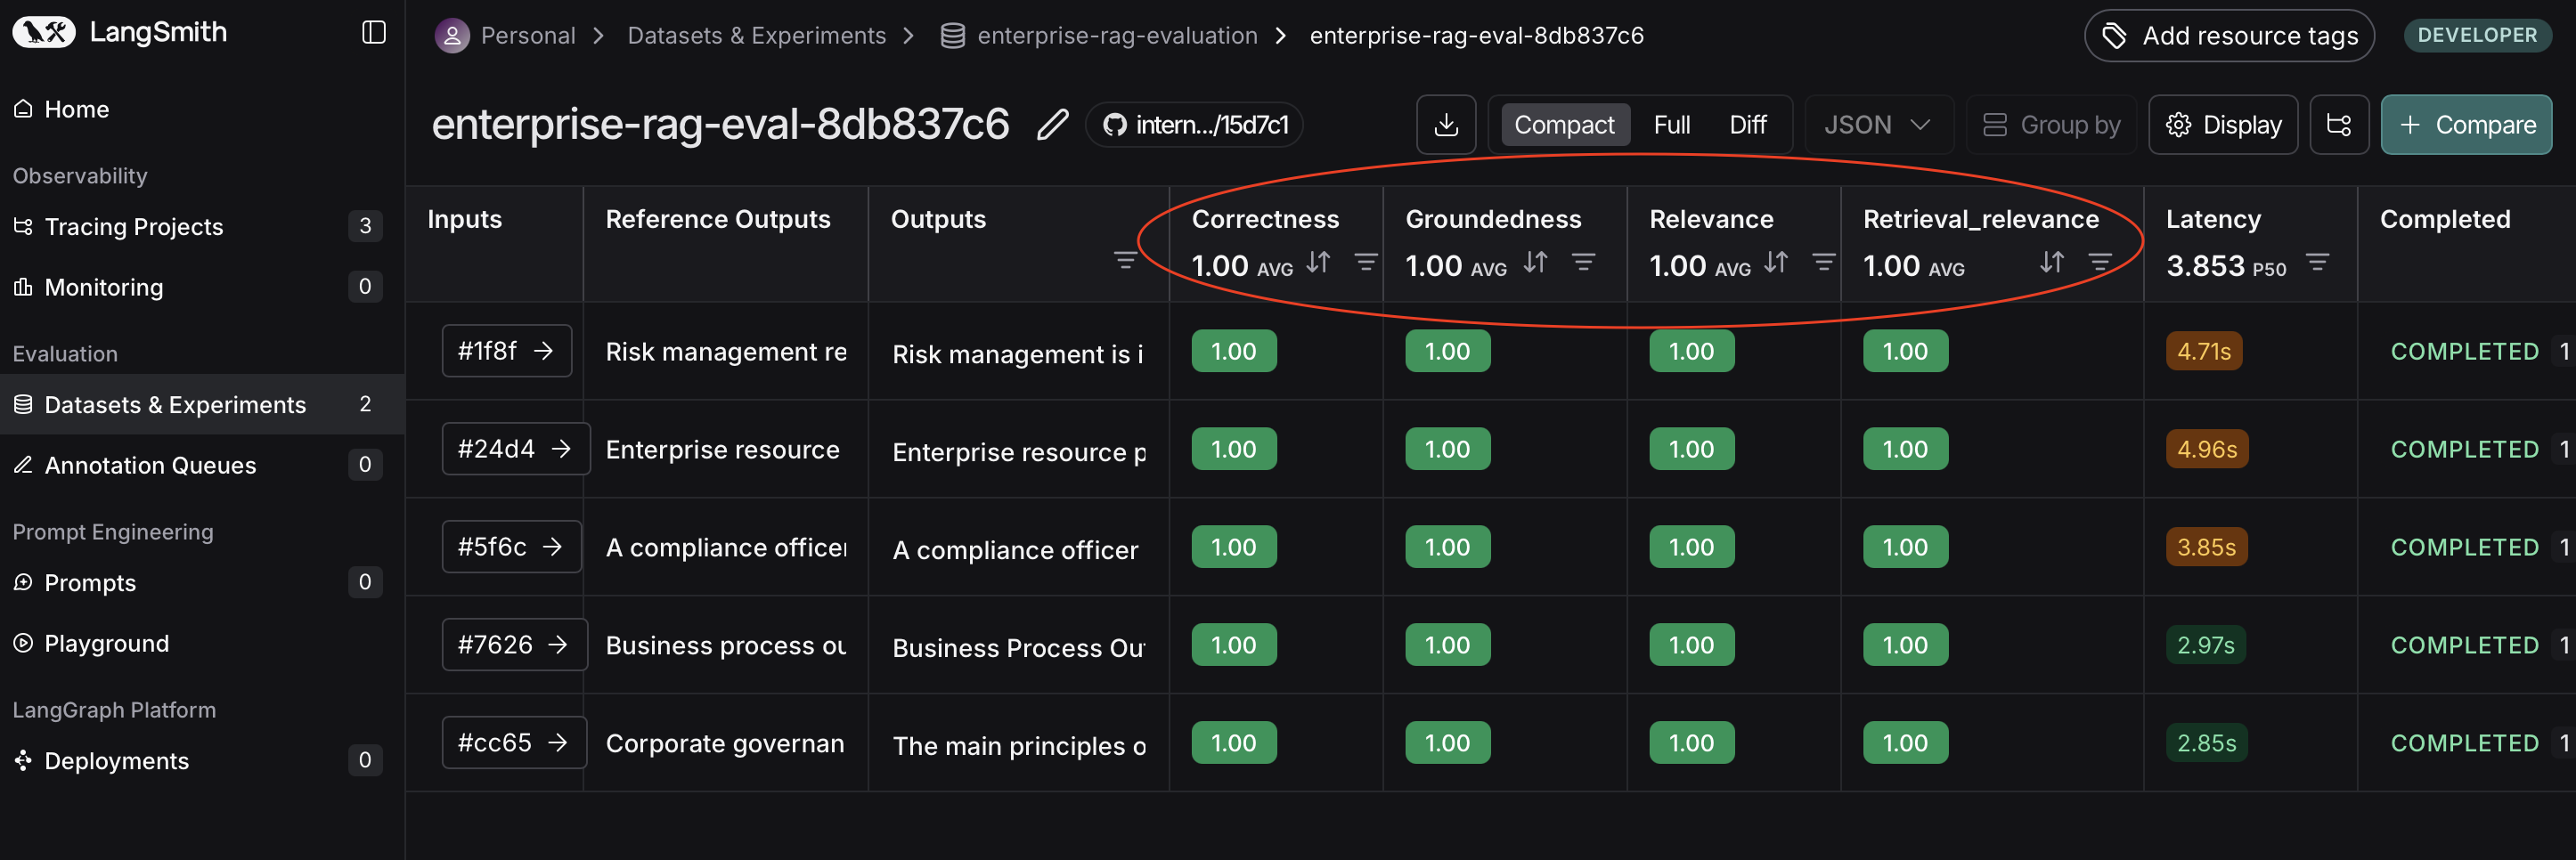

In [16]:
# Printing example of dataset
import os
from IPython.display import Image, display

notebook_dir = os.path.dirname(os.path.abspath(''))
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_10.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

### 5.1 Understanding Evaluation Results

The evaluation provides insights into different aspects of RAG performance:

- **High Correctness**: Responses are factually accurate
- **High Relevance**: Responses directly address user questions
- **High Groundedness**: Responses are supported by retrieved documents
- **High Retrieval Relevance**: Retrieved documents are relevant to questions

**Interpreting Results:**
- Scores close to 1.0 indicate excellent performance
- Scores below 0.7 may indicate areas for improvement
- Look for patterns across different question types or domains


### 5.2 Testing Individual Evaluators

Let's test our evaluators individually to understand how they work:


In [17]:
# Test individual evaluators with a sample question
test_question = "What are the key components of enterprise resource planning?"
print(f"Testing with question: {test_question}")

# Get RAG response
rag_response = enterprise_rag_assistant(test_question)
print(f"RAG Answer: {rag_response['answer'][:200]}...")

# Test each evaluator
test_inputs = {"question": test_question}
test_outputs = {"answer": rag_response["answer"], "documents": rag_response["documents"]}
test_reference = {"answer": "Enterprise Resource Planning (ERP) integrates core business processes like finance, HR, manufacturing, and supply chain management into a unified system."}

print("Evaluator Results:")

# Test correctness
try:
    correctness_score = correctness(test_inputs, test_outputs, test_reference)
    print(f"✓ Correctness: {correctness_score}")
except Exception as e:
    print(f"✗ Correctness error: {e}")

# Test relevance
try:
    relevance_score = relevance(test_inputs, test_outputs)
    print(f"✓ Relevance: {relevance_score}")
except Exception as e:
    print(f"✗ Relevance error: {e}")

# Test groundedness
try:
    groundedness_score = groundedness(test_inputs, test_outputs)
    print(f"✓ Groundedness: {groundedness_score}")
except Exception as e:
    print(f"✗ Groundedness error: {e}")

# Test retrieval relevance
try:
    retrieval_score = retrieval_relevance(test_inputs, test_outputs)
    print(f"✓ Retrieval Relevance: {retrieval_score}")
except Exception as e:
    print(f"✗ Retrieval relevance error: {e}")


Testing with question: What are the key components of enterprise resource planning?
RAG Answer: The key components of an enterprise resource planning (ERP) system generally include finance, human resources, logistics and manufacturing, supply chain management, and customer relationship managemen...
Evaluator Results:
✓ Correctness: True
✓ Relevance: True
✓ Groundedness: True
✓ Retrieval Relevance: True


---
## 6. Key Takeaways and Best Practices

### RAG Evaluation Framework Summary

We've implemented a comprehensive RAG evaluation system with four key dimensions:

1. **Correctness**: Measures factual accuracy against reference answers
2. **Relevance**: Ensures responses address user questions effectively  
3. **Groundedness**: Prevents hallucinations by checking document support
4. **Retrieval Relevance**: Validates quality of document retrieval

### Best Practices for RAG Evaluation

- **Multi-dimensional Assessment**: Use multiple evaluators to get comprehensive insights
- **LLM-as-Judge**: Leverage advanced models for sophisticated evaluation
- **Domain-Specific Prompts**: Tailor evaluation criteria to your business domain
- **Regular Evaluation**: Establish continuous evaluation processes
- **Human Validation**: Combine automated evaluation with human review

### Enterprise Considerations

- **Quality Standards**: Set appropriate thresholds for production deployment
- **Compliance**: Ensure evaluation meets regulatory requirements
- **Scalability**: Design evaluation systems that can handle enterprise-scale data
- **Documentation**: Maintain clear records of evaluation criteria and results


---

**Remember**: RAG evaluation is an ongoing process that requires continuous refinement based on real-world performance and evolving business requirements. Use evaluation insights to improve your RAG systems and ensure they meet enterprise quality standards!

---

Some of the concepts and examples in this material were adapted from the official [LangSmith RAG Evaluation documentation](https://docs.langchain.com/langsmith/evaluate-rag-tutorial). For more details, examples, and the latest updates, please refer directly to their site.
